In [3]:
from mpi4py import MPI
import numpy as np
import matplotlib.pyplot as plt

from h5 import HDFArchive
import coqui

Hartree_eV = 27.211386245988

--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin065 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------


Starting serial run at: 2026-05-17 13:32:20.607390


## Ab Initio GW+EDMFT for Quantum Materials

This tutorial provides an introduction ot the ab initio GW+EDMFT method for quantum materials. 

This tutorial will cover:
1. Initializing and executing a GW+EDMFT calculation

2. Important parameters and settings when performing GW+EDMFT calculations

3. Important observales/results obtained from GW+EDMFT calculations

## Realizing GW+EDMFT: CoQuí and TRIQS

<figure style="text-align: center;">
 <img src="../../images/gw_edmft_workflow.png" alt="GW+EDMFT workflow using CoQuí + TRIQS" width="65%">
 <figcaption>GW+EDMFT workflow using CoQuí + TRIQS.</figcaption>
</figure>

[Brief overivew on GW+EDMFT methodology and the physics it captures. Then describe the workflow for a self-consistent GW+EDMFT calculation and how CoQuí and TRIQS work together to realize it.] 

The workflow is split between CoQuí (orange boxes) and TRIQS (blue boxes), each with distinct responsibilities.

### Why CoQuí

1. Efficient ab initio GW with full frequency dependence in the full Hilbert space
2. Downfolding routines for projecting lattice $G$ and $W$ into MLWF subspaces and building impurity actions
3. Upfolding routines for embedding impurity corrections back into the lattice problem

[Brief decription on ModEST and CT-SEG impurity solver. We may need more details on CT-QMC solver since CoQui's users may have zero experience with TRIQS and its solvers, such as in [the solid_dmft tutorial](https://github.com/TRIQS/tutorials/blob/3.3.x/AbinitioDMFT/01-solid_dmft.ipynb).]
### Why TRIQS-ModEST and CT-SEG

1. Flexible mapping from MLWFs to impurity subspaces
2. Support for multiple impurities
3. Block structures and symmetry constraints that reduce cost and improve stability

Together, CoQuí handles full-basis tasks (GW, downfolding, upfolding), while TRIQS handles impurity-space construction and solution.

## Test system: NiO (paramagnetic charge-transfer insulator)

<figure style="text-align: center;">
 <img src="../../images/nio_gw_edmft_summary.png" alt="NiO" width="80%">
</figure>

Throughout this notebook, we use paramagnetic NiO as a representative correlated material.

**Physics background**
- NiO is a classic charge-transfer insulator with strong Ni 3d–O 2p hybridization.
- This makes double counting a central challenge in DFT+DMFT-type workflows.
- DFT and GW alone do not fully capture the insulating state.
- The Mott gap opens primarily in Ni $e_g$ orbitals and requires local correlations (DMFT/EDMFT).

**Starting point in this notebook**
- A pre-computed self-consistent GW solution for NiO
- MLWFs from a large window including Ni $d$ and O $p$ states (8 orbitals total)


In [2]:
# TODO run a python script to copy the following input files to here
# - `../../data/qe_inputs/nio/555/mlwf_dp/nio.mlwf.h5`: MLWFs for Ni $d$ + O $p$
# - `../../data/coqui/nio/555/nio.mbpt.h5`: pre-computed GW solution

### Section 1: GW+EDMFT 

[This section will focus on introducing `coqui.run_gw_edmft` function and its input/output. We will then show how to use it to run a self-consistent GW+EDMFT calculation for NiO, and analyze the results (spectral functions, self-energies, etc.) to see how the insulating state emerges.]

In [ ]:
!cat gw_edmft_params.toml

In [5]:
dmft_h5 = "/mnt/home/cyeh/ceph/coqui-tutorial/quickstart/04_gw_edmft/coqui/02_gw_edmft/rpa_screen/nio.dmft.h5"
with HDFArchive(dmft_h5, 'r') as f:
    print(f)

HDFArchive (partial view) with the following content:
  dmft : subgroup
  imaginary_fourier_transform : subgroup


In [2]:
dmft_h5 = "/mnt/home/cyeh/ceph/coqui-tutorial/quickstart/04_gw_edmft/coqui/02_gw_edmft/nio.dmft.h5"
iaft = coqui.IAFT.from_coqui_chkpt(dmft_h5)

solver_inputs = []
for it in range(50,100):
    inp = coqui.dmft.read_impurity_chkpt(dmft_h5, read="inputs", iteration=it)
    solver_inputs.append(inp[0])

solver_results = []
for it in range(50,100):
    res = coqui.dmft.read_impurity_chkpt(dmft_h5, read="results", iteration=it)
    solver_results.append(res[0])

Reading impurity checkpoint file: /mnt/home/cyeh/ceph/coqui-tutorial/quickstart/04_gw_edmft/coqui/02_gw_edmft/nio.dmft.h5
impurity list = [0]

Reading impurity checkpoint file: /mnt/home/cyeh/ceph/coqui-tutorial/quickstart/04_gw_edmft/coqui/02_gw_edmft/nio.dmft.h5
impurity list = [0]

Reading impurity checkpoint file: /mnt/home/cyeh/ceph/coqui-tutorial/quickstart/04_gw_edmft/coqui/02_gw_edmft/nio.dmft.h5
impurity list = [0]

Reading impurity checkpoint file: /mnt/home/cyeh/ceph/coqui-tutorial/quickstart/04_gw_edmft/coqui/02_gw_edmft/nio.dmft.h5
impurity list = [0]

Reading impurity checkpoint file: /mnt/home/cyeh/ceph/coqui-tutorial/quickstart/04_gw_edmft/coqui/02_gw_edmft/nio.dmft.h5
impurity list = [0]

Reading impurity checkpoint file: /mnt/home/cyeh/ceph/coqui-tutorial/quickstart/04_gw_edmft/coqui/02_gw_edmft/nio.dmft.h5
impurity list = [0]

Reading impurity checkpoint file: /mnt/home/cyeh/ceph/coqui-tutorial/quickstart/04_gw_edmft/coqui/02_gw_edmft/nio.dmft.h5
impurity list = [0]


#### 🔹 Convergence checking 

[Discuss the importance indicators/observables for checking convergence of GW+EDMFT calculations, inclulding impurity occupations, static screened interactions, chemical potential shift for impurity, specral weights at Fermi level $G(\tau=\beta/2)$, etc.. Convergence criteria of GW+EDMFT: $G_{loc} = G_{imp}$ and $W_{loc} = W_{imp}$ (if screen_type = rpa), changes in Weiss fields.]

[Mention how these indicators can be accessed from CoQui's GW+EDMFT output, and show examples of how to plot them as a function of iteration number to check for convergence.]

### Section 2: Analaysis of GW+EDMFT results

[In the previous section, we run a simple GW+EDMFT calculation with a couple of iterations and check the convergence of different indicators. In this section, we will analyze the results of a converged GW+EDMFT calculation (perhaps from a well-converged pre-computed checkpoint) to see how the insulating state emerges in NiO, and how the spectral functions, self-energies, and screened interactions from GW+EDMFT compared to GW alone.]

#### 🔹 Local spectral functions from impurity Green's function

#### 🔹 Local spectrum of the impurity screened interaction

#### 🔹 Effective interactions for V $t_{2g}$ and its comparison with cRPA

#### 🔹 Optical absorption spectrum

The GW+BSE method calculate the neutral excitation spectrum, presented as an optical absorption spectrum or the macroscopic dielectric function $\epsilon_M(\omega)$. In particular, the imaginary part of $\epsilon_M(\omega)$ is proportional to the optical absorption spectrum, which can be measured experimentally. 


#### 🔹 Local correlation functions

[TODO Check the dmft checkpoint file and visualize the local Green's function and local screened interaction $G_{\mathrm{loc}}$ and $W_{\mathrm{loc}}$.]

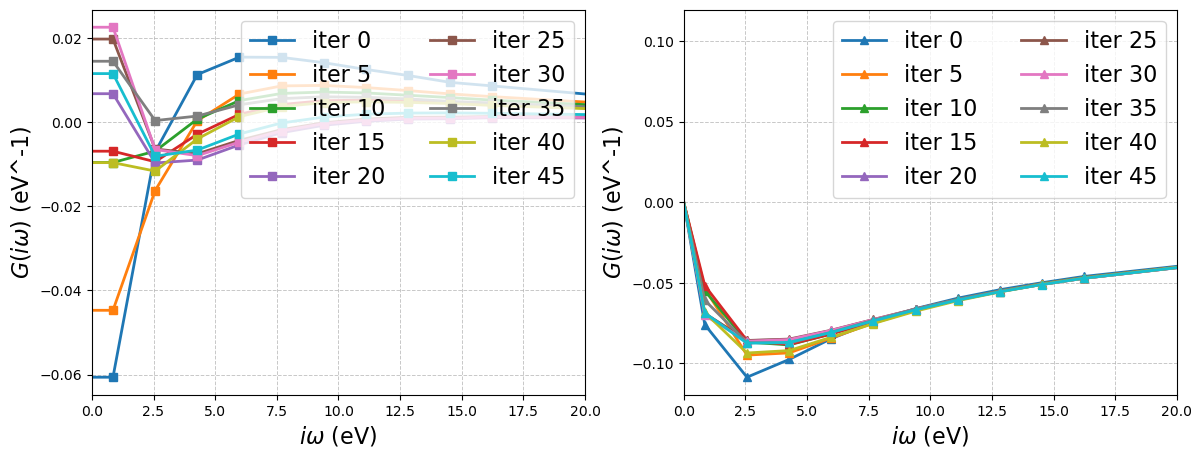

In [5]:
iw_mesh_f = iaft.wn_mesh('fermion') * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(1, 2, figsize=(14,5), dpi=100)
offset = 0
for i in range(offset, len(solver_inputs),5):
    G_iw_t2g = iaft.tau_to_w(solver_inputs[i]['Gloc_t'][0], 'f')

    ax[0].plot(iw_mesh_f, G_iw_t2g[:,0,0].real/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    #ax[0].plot(iw_mesh_f, solver_results[i]['G_iw_data'][0][:,0,0].real/Hartree_eV, 
    #        linestyle='--', marker='o', linewidth=2, label=f'iter {i}')
    ax[1].plot(iw_mesh_f, G_iw_t2g[:,0,0].imag/Hartree_eV, 
            linestyle='-', marker='^', linewidth=2, label=f'iter {i}')
    #ax[1].plot(iw_mesh_f, solver_results[i]['G_iw_data'][0][:,0,0].imag/Hartree_eV, 
    #        linestyle='--', marker='o', linewidth=2, label=f'iter {i}')

for i in range(2):
    ax[i].set_xlim(0, 20)
    ax[i].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i].set_ylabel("$G(i\omega)$ (eV^-1)", fontsize=16)
    ax[i].legend(ncol=2, loc=1, fontsize=16)
    ax[i].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

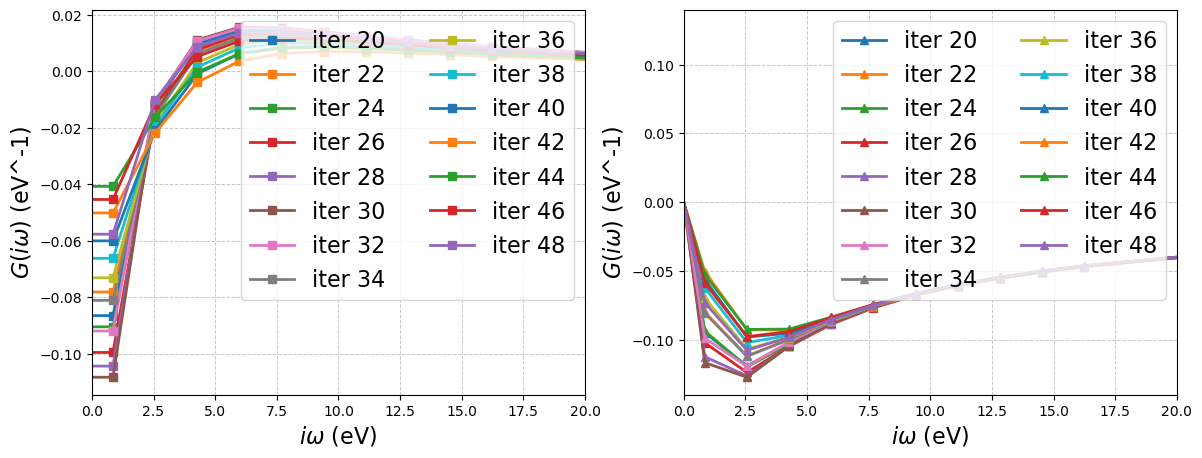

In [3]:
iw_mesh_f = iaft.wn_mesh('fermion') * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(1, 2, figsize=(14,5), dpi=100)
offset = 20
for i in range(offset, len(solver_inputs),2):
    G_iw_t2g = iaft.tau_to_w(solver_inputs[i]['Gloc_t'][0], 'f')

    ax[0].plot(iw_mesh_f, G_iw_t2g[:,0,0].real/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    #ax[0].plot(iw_mesh_f, solver_results[i]['G_iw_data'][0][:,0,0].real/Hartree_eV, 
    #        linestyle='--', marker='o', linewidth=2, label=f'iter {i}')
    ax[1].plot(iw_mesh_f, G_iw_t2g[:,0,0].imag/Hartree_eV, 
            linestyle='-', marker='^', linewidth=2, label=f'iter {i}')
    #ax[1].plot(iw_mesh_f, solver_results[i]['G_iw_data'][0][:,0,0].imag/Hartree_eV, 
    #        linestyle='--', marker='o', linewidth=2, label=f'iter {i}')

for i in range(2):
    ax[i].set_xlim(0, 20)
    ax[i].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i].set_ylabel("$G(i\omega)$ (eV^-1)", fontsize=16)
    ax[i].legend(ncol=2, loc=1, fontsize=16)
    ax[i].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

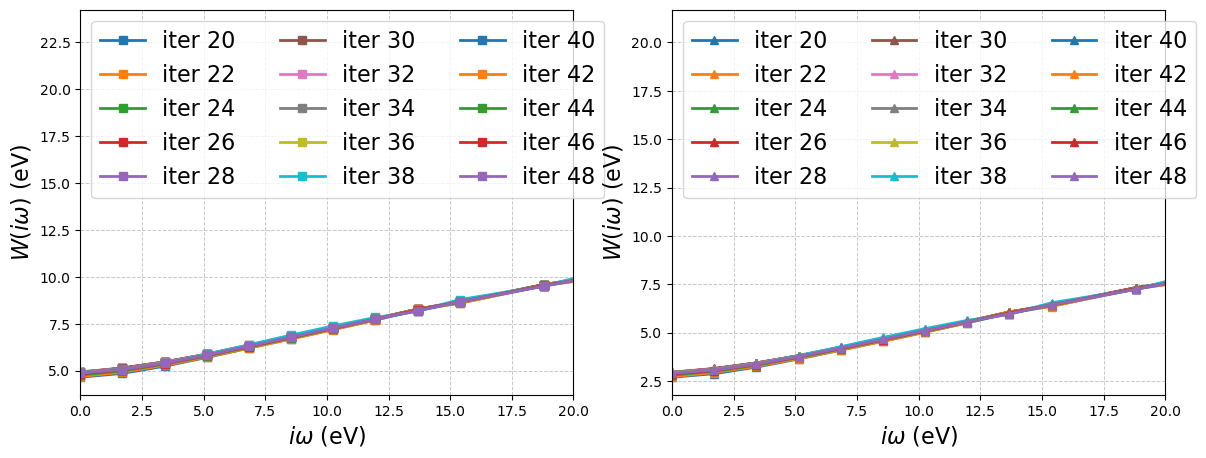

In [6]:
iw_mesh_b = iaft.wn_mesh('boson', positive_only=True) * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(1, 2, figsize=(14,5), dpi=100)
offset = 20
for i in range(offset, len(solver_inputs),2):
    W_iw = iaft.tau_to_w_phsym(solver_inputs[i]['Wloc_t'], 'boson')
    ax[0].plot(iw_mesh_b, (W_iw[:,0,0,0,0].real+solver_inputs[i]['Vloc'][0,0,0,0].real)*Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    #ax[0].plot(iw_mesh_b, (solver_results[i]['W_iw_data'][0][:,0,0].real+solver_inputs[i]['Vloc'][0,0,0,0].real)*Hartree_eV, 
    #        linestyle='--', marker='s', linewidth=2, label=f'iter {i}')
    ax[1].plot(iw_mesh_b, (W_iw[:,0,0,1,1].real+solver_inputs[i]['Vloc'][0,0,1,1].real)*Hartree_eV, 
            linestyle='-', marker='^', linewidth=2, label=f'iter {i}')
    #ax[1].plot(iw_mesh_b, (solver_results[i]['W_iw_data'][0][:,0,1].real+solver_inputs[i]['Vloc'][0,0,1,1].real)*Hartree_eV, 
    #        linestyle='--', marker='s', linewidth=2, label=f'iter {i}')

for i in range(2):
    ax[i].set_xlim(0, 20)
    #ax[i].set_ylim(-1, 10)
    ax[i].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i].set_ylabel("$W(i\omega)$ (eV)", fontsize=16)
    ax[i].legend(ncol=3, loc=2, fontsize=16)
    ax[i].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

#### 🔹 Impurity problem - Weiss fields 
[TODO Check the dmft checkpoint file and visualize the impurity Weiss fields $\mathcal{G}$ and $\mathcal{U}$.]

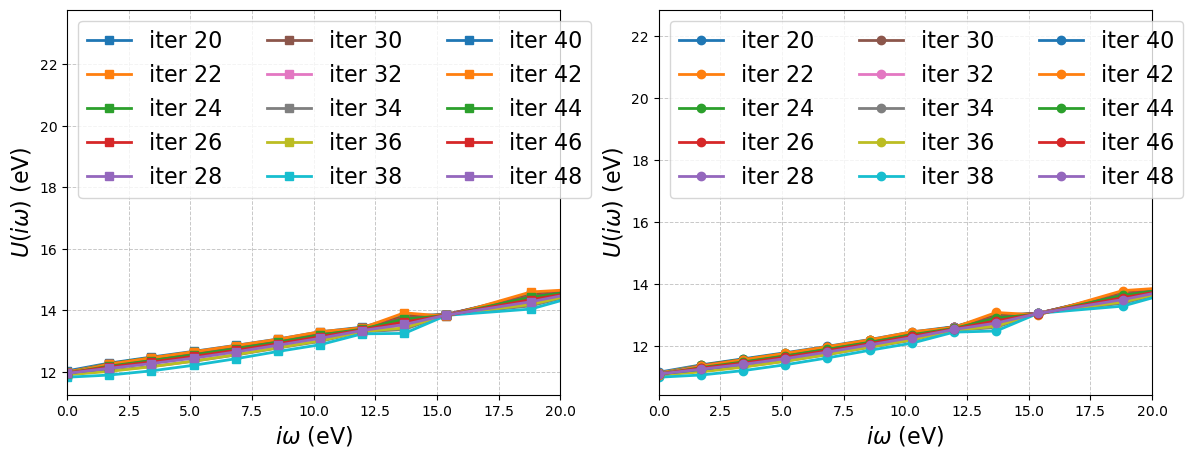

In [7]:
iw_mesh_b = iaft.wn_mesh('boson', positive_only=True) * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(1, 2, figsize=(14,5), dpi=100)
offset = 20
for i in range(offset,len(solver_inputs),2):
    ax[0].plot(iw_mesh_b, (solver_inputs[i]['u_weiss_iw'][:,0,0,0,0].real+solver_inputs[i]['Vloc'][0,0,0,0].real)*Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[1].plot(iw_mesh_b, (solver_inputs[i]['u_weiss_iw'][:,3,3,3,3].real+solver_inputs[i]['Vloc'][3,3,3,3].real)*Hartree_eV, 
            linestyle='-', marker='o', linewidth=2, label=f'iter {i}')

for i in range(2):
    ax[i].set_xlim(0, 20)
    #ax[i].set_ylim(2, 18)
    ax[i].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i].set_ylabel("$U(i\omega)$ (eV)", fontsize=16)
    ax[i].legend(ncol=3, loc=2, fontsize=16)
    ax[i].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

#### 🔹 Impurity solution
[TODO Check the dmft checkpoint file and visualize the impurity solutions $\Sigma_{\mathrm{imp}}$ and $\Pi_{\mathrm{imp}}$, and compare to the double counting solution.]

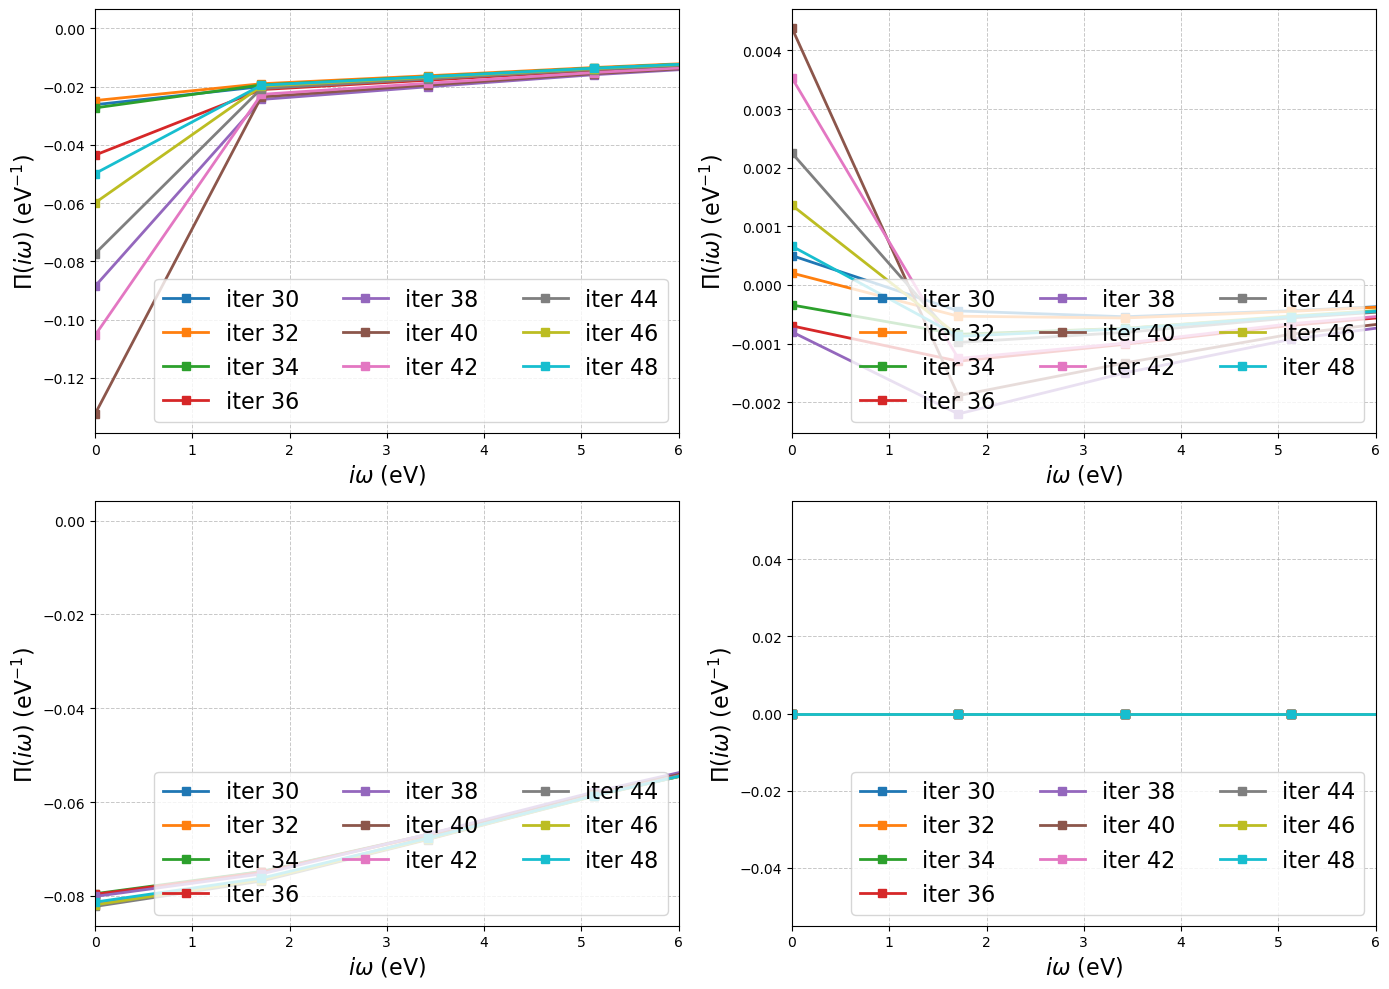

In [10]:
iw_mesh_b = iaft.wn_mesh('boson', positive_only=True) * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(2, 2, figsize=(14,10), dpi=100)

offset = 30
for i in range(offset,len(solver_results), 2):
    ax[0,0].plot(iw_mesh_b, (solver_results[i]['Pi_iw_data'][0][:,0,0].real)/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[0,1].plot(iw_mesh_b, (solver_results[i]['Pi_iw_data'][0][:,0,1].real)/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[1,0].plot(iw_mesh_b, (solver_results[i]['Pi_iw_dc_data'][0][:,0,0].real)/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[1,1].plot(iw_mesh_b, (solver_results[i]['Pi_iw_dc_data'][0][:,0,1].real)/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')

for ij in range(4):
    i = ij//2
    j = ij%2
    ax[i,j].set_xlim(0, 6)
    ax[i,j].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i,j].set_ylabel("$\Pi(i\omega)$ (eV$^{-1}$)", fontsize=16)
    ax[i,j].legend(ncol=3, loc=4, fontsize=16)
    ax[i,j].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    ax[i,j].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

plt.tight_layout()

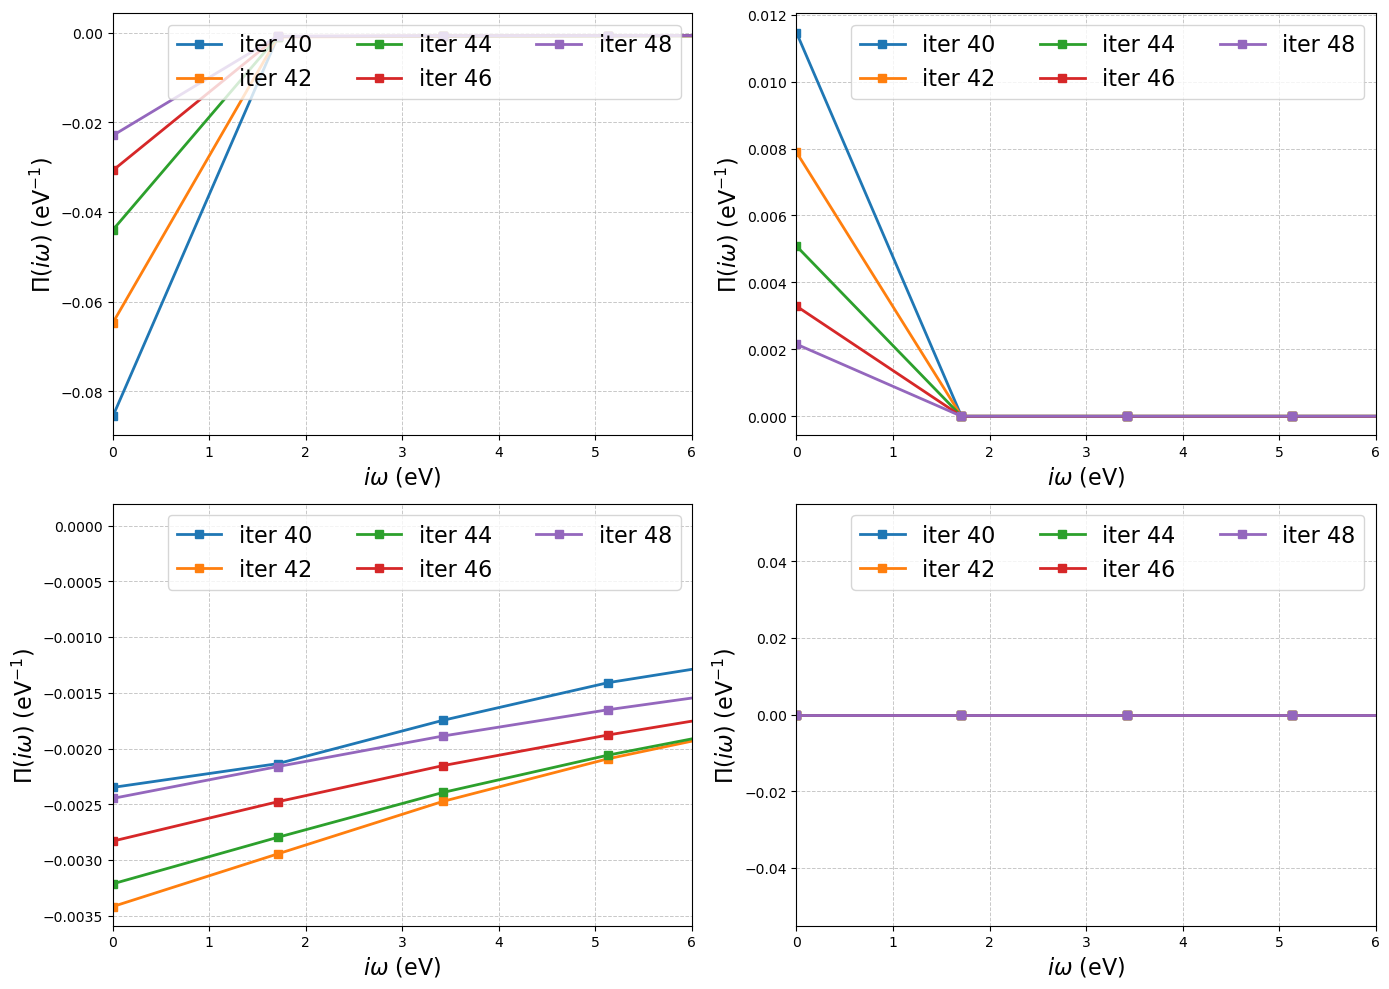

In [12]:
iw_mesh_b = iaft.wn_mesh('boson', positive_only=True) * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(2, 2, figsize=(14,10), dpi=100)
offset = 40
for i in range(offset,len(solver_results),2):
    ax[0,0].plot(iw_mesh_b, (solver_results[i]['Pi_iw_data'][0][:,3,3].real)/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[0,1].plot(iw_mesh_b, (solver_results[i]['Pi_iw_data'][0][:,3,4].real)/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[1,0].plot(iw_mesh_b, (solver_results[i]['Pi_iw_dc_data'][0][:,3,3].real)/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[1,1].plot(iw_mesh_b, (solver_results[i]['Pi_iw_dc_data'][0][:,3,4].real)/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')

for ij in range(4):
    i = ij//2
    j = ij%2
    ax[i,j].set_xlim(0, 6)
    ax[i,j].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i,j].set_ylabel("$\Pi(i\omega)$ (eV$^{-1}$)", fontsize=16)
    ax[i,j].legend(ncol=3, loc=1, fontsize=16)
    ax[i,j].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    ax[i,j].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

plt.tight_layout()

In [13]:
for i in range(len(solver_results)):
    vhf_dc = solver_results[i]['Sigma_infty_dc'][0][0,0]
    vhf_imp = solver_results[i]['Sigma_infty'][0][0,0]
    print(f"Vhf imp = {vhf_imp.real}, Vhf dc = {vhf_dc.real}, diff = {vhf_imp.real-vhf_dc.real}")

Vhf imp = 2.4067617508224295, Vhf dc = 2.3892402383897386, diff = 0.017521512432690844
Vhf imp = 2.392189092333037, Vhf dc = 2.37350947056738, diff = 0.01867962176565685
Vhf imp = 2.3925700652475874, Vhf dc = 2.3774309763383403, diff = 0.01513908890924709
Vhf imp = 2.3967220417808166, Vhf dc = 2.3857298009748673, diff = 0.010992240805949294
Vhf imp = 2.4002783965189223, Vhf dc = 2.3904906997615565, diff = 0.009787696757365794
Vhf imp = 2.4058906570223426, Vhf dc = 2.4002167253713176, diff = 0.005673931651025033
Vhf imp = 2.4104910281373915, Vhf dc = 2.40721650632189, diff = 0.0032745218155012523
Vhf imp = 2.4149249531546007, Vhf dc = 2.413735925890892, diff = 0.0011890272637087307
Vhf imp = 2.420933420517709, Vhf dc = 2.425056838203862, diff = -0.004123417686153097
Vhf imp = 2.4253091033686767, Vhf dc = 2.4324683342486413, diff = -0.007159230879964618
Vhf imp = 2.425911663278274, Vhf dc = 2.429139727847226, diff = -0.0032280645689524157
Vhf imp = 2.426698334062086, Vhf dc = 2.428539787

In [14]:
for i in range(len(solver_results)):
    vhf_dc = solver_results[i]['Sigma_infty_dc'][3][0,0]
    vhf_imp = solver_results[i]['Sigma_infty'][3][0,0]
    print(f"Vhf imp = {vhf_imp.real}, Vhf dc = {vhf_dc.real}, diff = {vhf_imp.real-vhf_dc.real}")

Vhf imp = 2.0154430729319, Vhf dc = 2.017811342911252, diff = -0.0023682699793519113
Vhf imp = 2.006064398867822, Vhf dc = 2.00995186597342, diff = -0.0038874671055979526
Vhf imp = 2.009020075496264, Vhf dc = 2.0123175694091096, diff = -0.003297493912845617
Vhf imp = 2.012338865201984, Vhf dc = 2.01659702700398, diff = -0.004258161801995897
Vhf imp = 2.014540017119257, Vhf dc = 2.020024384116948, diff = -0.005484366997690948
Vhf imp = 2.018122747578963, Vhf dc = 2.0248937999732655, diff = -0.006771052394302313
Vhf imp = 2.0207574334968292, Vhf dc = 2.0283291355489266, diff = -0.00757170205209734
Vhf imp = 2.0231583471923797, Vhf dc = 2.031237216951208, diff = -0.008078869758828322
Vhf imp = 2.02660582752852, Vhf dc = 2.0347601788055596, diff = -0.008154351277039673
Vhf imp = 2.0285064049886516, Vhf dc = 2.036767845916721, diff = -0.008261440928069241
Vhf imp = 2.0279984798777866, Vhf dc = 2.036326498342428, diff = -0.008328018464641485
Vhf imp = 2.0280077725853602, Vhf dc = 2.035780309

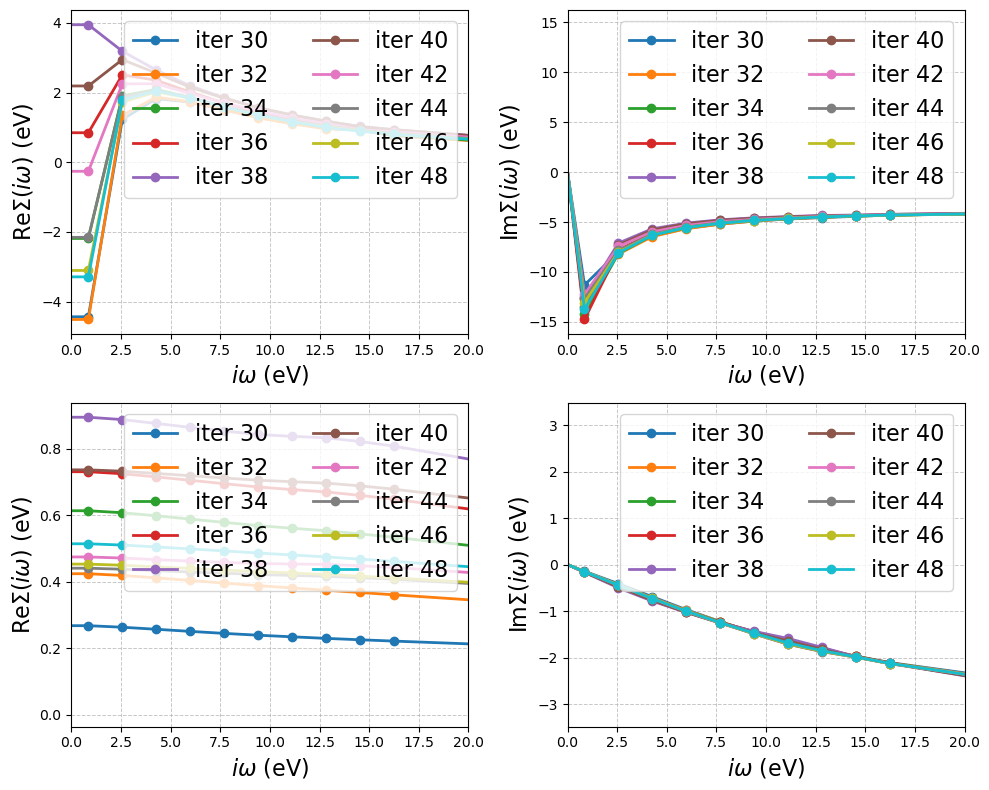

In [15]:
iw_mesh_f = iaft.wn_mesh('fermion') * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(2, 2, figsize=(10,8), dpi=100)
offset = 30
for i in range(offset,len(solver_results), 2):
    ax[0,0].plot(iw_mesh_f, solver_results[i]['Sigma_iw_data'][0][:,0,0].real*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[0,1].plot(iw_mesh_f, solver_results[i]['Sigma_iw_data'][0][:,0,0].imag*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[1,0].plot(iw_mesh_f, solver_results[i]['Sigma_iw_dc_data'][0][:,0,0].real*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[1,1].plot(iw_mesh_f, solver_results[i]['Sigma_iw_dc_data'][0][:,0,0].imag*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')

for i in range(2):
    ax[i,0].set_xlim(0, 20)
    ax[i,0].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i,0].set_ylabel("Re$\Sigma(i\omega)$ (eV)", fontsize=16)
    ax[i,0].legend(loc=1, ncol=2, fontsize=16)
    ax[i,0].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    ax[i,0].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

for i in range(2):
    ax[i,1].set_xlim(0, 20)
    #ax[i,1].set_ylim(-2.5, 0.0)
    ax[i,1].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i,1].set_ylabel("Im$\Sigma(i\omega)$ (eV)", fontsize=16)
    ax[i,1].legend(loc=1, ncol=2, fontsize=16)
    ax[i,1].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    ax[i,1].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
 
plt.tight_layout()

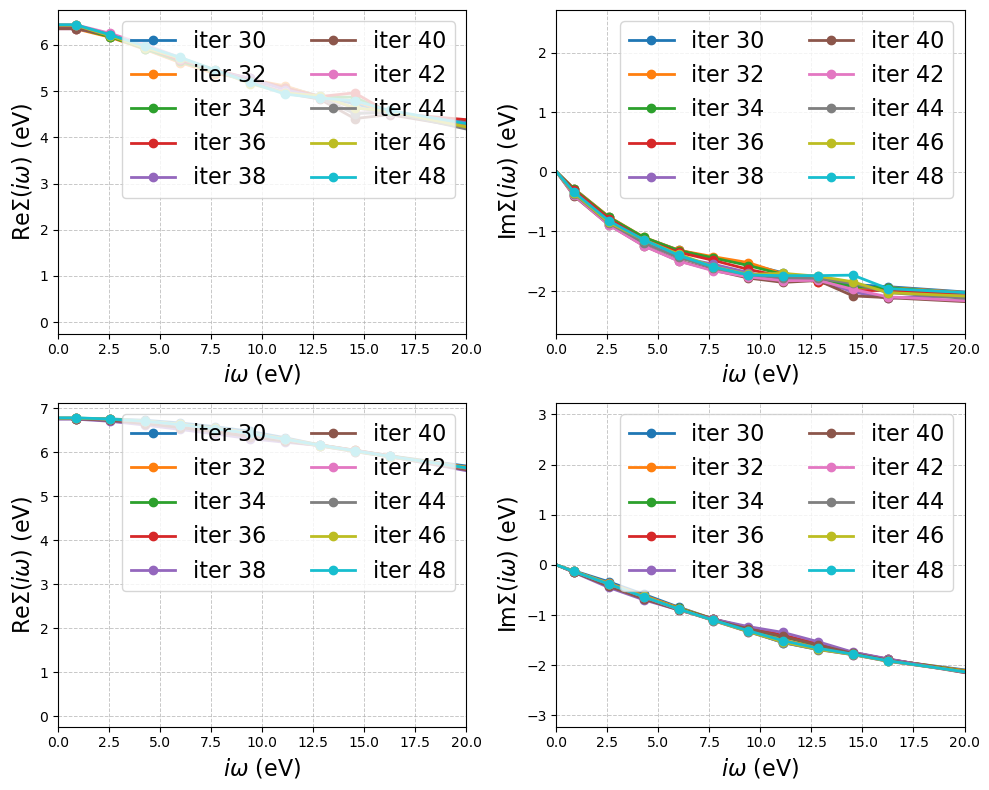

In [16]:
iw_mesh_f = iaft.wn_mesh('fermion') * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(2, 2, figsize=(10,8), dpi=100)
offset = 30
for i in range(offset,len(solver_results),2):
    ax[0,0].plot(iw_mesh_f, solver_results[i]['Sigma_iw_data'][3][:,0,0].real*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[0,1].plot(iw_mesh_f, solver_results[i]['Sigma_iw_data'][3][:,0,0].imag*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[1,0].plot(iw_mesh_f, solver_results[i]['Sigma_iw_dc_data'][3][:,0,0].real*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[1,1].plot(iw_mesh_f, solver_results[i]['Sigma_iw_dc_data'][3][:,0,0].imag*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')

for i in range(2):
    ax[i,0].set_xlim(0, 20)
    ax[i,0].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i,0].set_ylabel("Re$\Sigma(i\omega)$ (eV)", fontsize=16)
    ax[i,0].legend(loc=1, ncol=2, fontsize=16)
    ax[i,0].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    ax[i,0].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

for i in range(2):
    ax[i,1].set_xlim(0, 20)
    #ax[i,1].set_ylim(-2.5, 0.0)
    ax[i,1].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i,1].set_ylabel("Im$\Sigma(i\omega)$ (eV)", fontsize=16)
    ax[i,1].legend(loc=1, ncol=2, fontsize=16)
    ax[i,1].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    ax[i,1].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
 
plt.tight_layout()